<a href="https://colab.research.google.com/github/Devadeth-cmyk/vehicle-damage-insurance-ai/blob/main/test_fusion_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00


In [3]:
import sys, os

PROJECT_ROOT = '/content/drive/MyDrive/AI ML/Projects'
INFERENCE_DIR = f'{PROJECT_ROOT}/inference'
sys.path.insert(0, INFERENCE_DIR)

for fname in ['damage_detector.py', 'parts_detector.py', 'fusion.py', 'claim_analyzer.py', 'visualize.py']:
    path = os.path.join(INFERENCE_DIR, fname)
    print(f'{fname}: {"FOUND" if os.path.exists(path) else "MISSING - upload it to " + INFERENCE_DIR}')

damage_detector.py: FOUND
parts_detector.py: FOUND
fusion.py: FOUND
claim_analyzer.py: FOUND
visualize.py: FOUND


#Set Model Paths

In [4]:
PROJECT_ROOT = "/content/drive/MyDrive/AI ML/Projects"

DAMAGE_MODEL = f"{PROJECT_ROOT}/models/damage/best.pt"
PARTS_MODEL = f"{PROJECT_ROOT}/models/parts/parts.pt"

print(DAMAGE_MODEL)
print(PARTS_MODEL)

Damage model exists: True
Parts model exists: True


#Load the Claim Analyzer

In [5]:
from claim_analyzer import ClaimAnalyzer

analyzer = ClaimAnalyzer(DAMAGE_MODEL_PATH, PARTS_MODEL_PATH)
print('Damage model classes:', analyzer.damage_detector.model.names)
print('Parts model classes:', analyzer.parts_detector.model.names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Damage model classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
Parts model classes: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}


#Upload a Test Image

In [23]:
IMAGE_PATH = "/content/drive/MyDrive/AI ML/Projects/vehicle_damage_project/test_images/car.jpg"

print(os.path.exists(IMAGE_PATH))

Saving 000513.jpg to 000513.jpg
Uploaded: 000513.jpg


# Run the Full Fusion Pipeline on One Image

In [24]:
import json

result = analyzer.analyze_image(test_image_path)
print(json.dumps(result, indent=2))

{
  "image": "000513.jpg",
  "status": "completed",
  "detections": [
    {
      "part": "front_bumper",
      "damage_type": "dent",
      "severity": null,
      "damage_confidence": 0.662,
      "part_confidence": 0.609,
      "overlap_score": 0.431,
      "bbox": [
        156.6,
        168.7,
        718.5,
        318.4
      ],
      "requires_review": false
    },
    {
      "part": "unknown",
      "damage_type": "glass shatter",
      "severity": null,
      "damage_confidence": 0.562,
      "part_confidence": null,
      "overlap_score": 0.11,
      "bbox": [
        117.0,
        85.7,
        494.2,
        170.3
      ],
      "requires_review": true,
      "review_reason": "no_part_matched"
    },
    {
      "part": "front_bumper",
      "damage_type": "dent",
      "severity": null,
      "damage_confidence": 0.507,
      "part_confidence": 0.609,
      "overlap_score": 1.0,
      "bbox": [
        97.2,
        242.0,
        206.3,
        362.6
      ],
      "r

# Generate Annotated Image

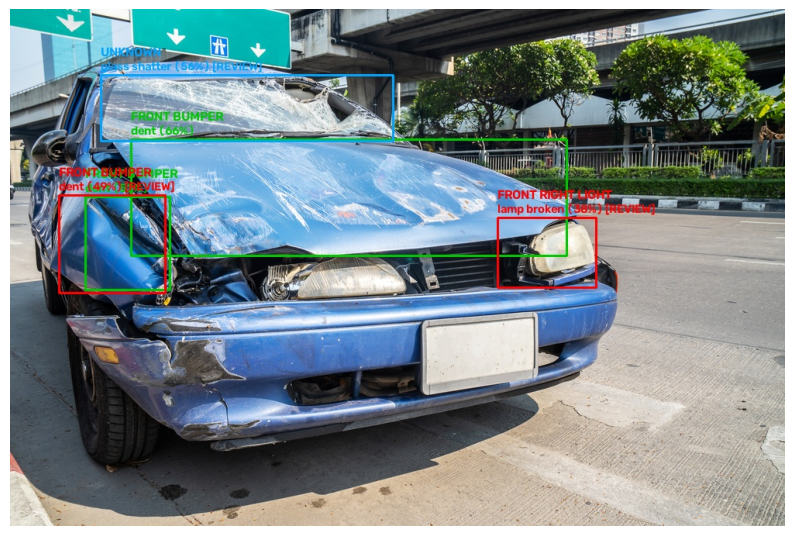

In [25]:
from visualize import annotate_image
import matplotlib.pyplot as plt
import cv2

output_path = 'annotated_result.jpg'
annotate_image(test_image_path, result['detections'], output_path)

img = cv2.cvtColor(cv2.imread(output_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

#Test Multi-Image Claim Processing

In [26]:
# Upload a few more images to simulate a multi-photo claim, or reuse the same one for a quick test
claim_result = analyzer.analyze_claim(claim_id='CLM-2026-00125', image_paths=[test_image_path])
print(json.dumps(claim_result, indent=2))

{
  "claim_id": "CLM-2026-00125",
  "damage_model_version": "cardd-v1",
  "parts_model_version": "parts-v1",
  "images": [
    {
      "image": "000513.jpg",
      "status": "completed",
      "detections": [
        {
          "part": "front_bumper",
          "damage_type": "dent",
          "severity": null,
          "damage_confidence": 0.662,
          "part_confidence": 0.609,
          "overlap_score": 0.431,
          "bbox": [
            156.6,
            168.7,
            718.5,
            318.4
          ],
          "requires_review": false
        },
        {
          "part": "unknown",
          "damage_type": "glass shatter",
          "severity": null,
          "damage_confidence": 0.562,
          "part_confidence": null,
          "overlap_score": 0.11,
          "bbox": [
            117.0,
            85.7,
            494.2,
            170.3
          ],
          "requires_review": true,
          "review_reason": "no_part_matched"
        },
        {
 